# Sea Ice Comparisons to Observations

This script shows how to load and plot sea ice concentration from CICE output and compare it to the NSIDC CDR (National Snow and Ice Data Centre, Climate Data Record) dataset

This notebook uses the _ACCESS-NRI Intake Catalog_ following the examples in [Tutorials/Using the Intake Catalog](https://cosima-recipes.readthedocs.io/en/latest/01-Cooking-Tutorials/01-Basics/02-ACCESS-NRI_Intake_Catalog.html). 

Requirements: This was tested using `conda/analysis3-26.07` from `/g/data/xp65/public/modules` and a _medium_ instance on _normalsr_ queue (although we recommend a larger instance if making iterative changes). Observational data is sourced from `av17` project, everyone is welcome to join.

**OM2 Experiments:**

These are the ACCESS-OM2 runs we are going to use, we can compare results from runs using JRA55do, as [described on the ACCESS-HIVE forum](https://forum.access-hive.org.au/t/era-5-forced-access-om2-simulations/1103/5). To compare against the observational datasets, we use IAF (Inter-Annual Forcing). _N.B._ The JRA55do runs used here a slightly different to the typical (e.g. _1deg_jra55_iaf_omip2_cycle6_) in the model version used and the timeframes evaluated.

In [1]:
OM2_EXPT = "1deg_jra55_iaf_era5comparison"

We are going to look at Sea Ice Concentration and Sea Ice Volume

In [2]:
VARS = ["aice_m", "hi_m" ]  # ice area fraction or sea ice concentration, ice thickness averaged by grid cell area
VARS_FX = ["area_t", "geolat_t", "geolon_t"]

**Observational Data:**

Sea Ice concentration is measured through passive microwave remote sensing. We are going to use the NSIDC CDR Dataset (described at [nsidc.org](https://nsidc.org/data/g02202/versions/6))

In [3]:
OBS_TIME_SLICE = slice("1979", "2022")
OBS_PATH = "/g/data/av17/access-nri/OM3/CDR_G02202_V6"
SH_OBS_PATH = f"{OBS_PATH}/south/monthly/sic_pss25*.nc"
SH_OBS_AREAS_P = "/g/data/av17/access-nri/OM3/CDR_G02202_V5/NSIDC-G02202-sh/pss25area_v3.dat"
SH_OBS_LATLON_P = "/g/data/av17/access-nri/OM3/CDR_G02202_V5/NSIDC-G02202-sh/G02202-cdr-ancillary-sh.nc"
NH_OBS_PATH = f"{OBS_PATH}/north/monthly/sic_psn25*.nc"
NH_OBS_AREAS_P = "/g/data/av17/access-nri/OM3/CDR_G02202_V5/NSIDC-G02202-nh/G02202-cdr-ancillary-nh.nc"

**Load depenencies:**

In [4]:
import intake

from dask.distributed import Client

import xarray as xr
import numpy as np
from datetime import timedelta
import cf_xarray as cfxr
import xesmf

# plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean.cm as cmo
import matplotlib.lines as mlines

A standard way to calculate climatologies. (We start in 1991 as earlier decades are influenced by model spin-up for 0.25deg runs which only start in 1980, but arguably could use an earlier period for a cooler climate)

In [5]:
CLIMAT_TIME_SLICE = slice("1991", "2020")

def climatology(ds):
    return ds.sel(time=CLIMAT_TIME_SLICE).groupby("time.month").mean("time")

Start a dask client

In [6]:
client = Client(threads_per_worker = 1)

client.dashboard_link

'/proxy/8787/status'

Open the _ACCESS-NRI Intake Catalog_

In [7]:
catalog = intake.cat.access_nri

# Load the ACCESS-OM2 results

For CICE data in OM2, we need to do some wrangling to make it easier to deal with. This is described in more detail in [DocumentedExamples/SeaIce_Plot_Example](https://cosima-recipes.readthedocs.io/en/latest/02-Easy-Recipes/Sea_Ice_Coordinates.html). Its included in this function:

In [8]:
def open_by_name(name, vars):
    """Return a dataset for the requested name and vars"""

    return (
        catalog[name]
        .search(variable=vars)
        .to_dask(
            xarray_open_kwargs={
                "chunks": -1 ,
                "decode_coords": False,
            },
            xarray_combine_by_coords_kwargs={
                "compat": "override",
                "data_vars": "minimal",
                "coords": "minimal",
            },
        )
    )

In [9]:
def open_by_experiment(exp_name, vars):
    """Concatenate any datasets provided for this experiment into one ds, and add area and geo coordinates"""

    # get the data for each run of this config
    cice_ds = open_by_name(exp_name, vars)

    # We also want the area/lat/lon fields, these are separate datasets, so lets merge them.
    area_ds = xr.merge(
        [open_by_name(exp_name, iVar) for iVar in VARS_FX]
    ).load()

    # Label the lats and lons
    cice_ds.coords["ni"] = area_ds["xt_ocean"].values
    cice_ds.coords["nj"] = area_ds["yt_ocean"].values

    # Copy attributes for cf compliance
    cice_ds.ni.attrs = area_ds.xt_ocean.attrs
    cice_ds.nj.attrs = area_ds.yt_ocean.attrs

    cice_ds = cice_ds.rename(({"ni": "xt_ocean", "nj": "yt_ocean"}))

    # Add the geolon, geolat, and area as extra co-ordinates fields from area_t

    cice_ds = cice_ds.assign_coords(
        {
            "geolat_t": area_ds.geolat_t,
            "geolon_t": area_ds.geolon_t,
            "area_t": area_ds.area_t,
        }
    )

    # cice timestamps are also misleading:
    cice_ds["time"] = cice_ds.time.to_pandas() - timedelta(minutes=1)

    return cice_ds

In [10]:
om2_ds = open_by_experiment(OM2_EXPT, VARS)

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/access_nri_intake/aliases.py:192: UserWarning: Value aliasing: variable='aice_m' → variable=['aice_m','aice_m']
  norm: dict[str, Any] = self._normalise_kwargs(kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/access_nri_intake/aliases.py:192: UserWarning: Value aliasing: variable='hi_m' → variable=['hi_m','hi_m']
  norm: dict[str, Any] = self._normalise_kwargs(kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/intake_esm/source.py:314: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/intake_esm/source.py:314: ConcatenationWarning: Attempting to concatenate datasets without valid dimens

Align times to same format as observations

In [11]:
om2_ds["time"] = [
        np.datetime64(str(i)[0:7] + "-01T00:00:00.000000000")
        for i in om2_ds.time.values
    ]

In [12]:
om2_ds

<xarray.Dataset> Size: 623MB
Dimensions:   (time: 720, yt_ocean: 300, xt_ocean: 360)
Coordinates:
  * time      (time) datetime64[ns] 6kB 1959-01-01 1959-02-01 ... 2019-12-01
  * yt_ocean  (yt_ocean) float64 2kB -77.88 -77.63 -77.38 ... 88.87 89.32 89.77
  * xt_ocean  (xt_ocean) float64 3kB -279.5 -278.5 -277.5 ... 77.5 78.5 79.5
    geolat_t  (yt_ocean, xt_ocean) float32 432kB nan nan nan ... 65.63 65.21
    geolon_t  (yt_ocean, xt_ocean) float32 432kB nan nan nan ... 79.97 79.99
    area_t    (yt_ocean, xt_ocean) float32 432kB nan nan ... 1.121e+08 3.857e+07
Data variables:
    aice_m    (time, yt_ocean, xt_ocean) float32 311MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    hi_m      (time, yt_ocean, xt_ocean) float32 311MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
Attributes: (12/18)
    title:                                    sea ice model output for CICE
    contents:                                 Diagnostic and Prognostic Varia...
    source:                                   Los Alamos Sea Ice Model (CICE)...
    time_period_freq:                         month_1
    comment3:                                 seconds elapsed into model date...
    conventions:                              CF-1.0
    ...                                       ...
    intake_esm_attrs:variable_standard_name:  ,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,...
    intake_esm_attrs:variable_cell_methods:   ,,,,,,,time: mean,time: mean,,,...
    intake_esm_attrs:realm:                   seaIce
    intake_esm_attrs:temporal_label:          mean
    intake_esm_attrs:_data_format_:           netcdf
    intake_esm_dataset_key:                   seaIce.1mon.d2:2.nc:5.ni:360.nj...

# Load the observational dataset

The CDR dataset has the area of each grid cell provided as a separate file, which we need to load

In [13]:
def open_cdr_dataset(path, area_file):
    ds = xr.open_mfdataset(path, parallel=True).rename(
        {'cdr_seaice_conc_monthly': 'cdr_conc'}
    )

    # # we also need the area of each gridcell
    areasNd = np.fromfile(area_file, dtype=np.int32).reshape(
        ds.cdr_conc.isel(time=0).shape
    )
    # # Divide by 1000 to get km2 (https://web.archive.org/web/20170817210544/http://nsidc.org/data/polar-stereo/tools_geo_pixel.html#pixel_area)
    areasKmNd_sh = areasNd / 1000
        
    ds["area"] = xr.DataArray(areasKmNd_sh, dims=["y", "x"])
    ds = ds.set_coords("area")

    ds["cdr_conc"] = ds.cdr_conc.where(ds.cdr_conc<=1)  # convert error codes to Nan

    return ds

We are interested in the Antarctic, but the lines for the Arctic are below and commented out.

In [14]:
cdr_obs_ds = open_cdr_dataset(SH_OBS_PATH, SH_OBS_AREAS_P).load()

# cdr_obs_ds = open_cdr_dataset(NH_OBS_PATH, NH_OBS_AREAS_P)

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/argopy/utils/lists.py:38: UserWarning: An error occurred while loading the ERDDAP data fetcher, it will not be available !
<class 'ImportError'>
cannot import name '_quote_string_constraints' from 'erddapy.erddapy' (/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/erddapy/erddapy.py)
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/argopy/utils/lists.py:50: UserWarning: An error occurred while loading the ArgoVis data fetcher, it will not be available !
<class 'ImportError'>
cannot import name '_quote_string_constraints' from 'erddapy.erddapy' (/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/erddapy/erddapy.py)
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/argopy/utils/lists.py:66: UserWarning: An error occurred while loadi

In [15]:
cdr_obs_ds

<xarray.Dataset> Size: 780MB
Dimensions:                          (time: 571, y: 332, x: 316)
Coordinates:
  * time                             (time) datetime64[ns] 5kB 1978-11-01 ......
  * y                                (y) float64 3kB 4.338e+06 ... -3.938e+06
  * x                                (x) float64 3kB -3.938e+06 ... 3.938e+06
    area                             (y, x) float64 839kB 444.1 445.0 ... 460.1
Data variables:
    cdr_conc                         (time, y, x) float32 240MB 0.0 0.0 ... 0.0
    cdr_seaice_conc_monthly_stdev    (time, y, x) float64 479MB 0.0 0.0 ... 0.0
    cdr_seaice_conc_monthly_qa_flag  (time, y, x) uint8 60MB 16 16 16 ... 80 80
    crs                              (time) int32 2kB -2147483647 ... -214748...
Attributes: (12/46)
    Conventions:               CF-1.11, ACDD-1.3
    date_created:              2025-10-01T20:22:56Z
    time_coverage_start:       1978-11-01T00:00:00Z
    time_coverage_end:         1978-11-30T23:59:59Z
    time_coverage_resolution:  P1M
    time_coverage_duration:    P1M
    ...                        ...
    geospatial_lat_min:        -90.0
    geospatial_lat_max:        -39.23089
    geospatial_lon_min:        -180.0
    geospatial_lon_max:        180.0
    geospatial_lat_units:      degrees_north
    geospatial_lon_units:      degrees_east

# Calculate Sea Ice Area

Sea ice area is the circumpolar sum of sea ice concentration multiplied by the area of each grid cell. By convention, and because lower concentrations are not accurate when measured through remote sensing, concentrations below 0.15 are not included

In [16]:
def sea_ice_weighted_sum(sic, area, range=[0.15, 1]):
    return (sic * area).where((sic >= range[0]) * (sic <= range[1])).cf.sum(["X", "Y"])

Calculate for observational data, and remove gaps with missing data

In [17]:
def sea_ice_area_obs(ds):
   
    sic = ds.cdr_conc
    result = sea_ice_weighted_sum(sic, sic.area).to_dataset(name="cdr_area")

    # Theres a couple of data gaps which should be nan
    result.loc[{"time": "1988-01-01"}] = np.nan
    result.loc[{"time": "1987-12"}] = np.nan

    return result.sel(time=OBS_TIME_SLICE)

In [18]:
obs_area_ds = sea_ice_area_obs(cdr_obs_ds)

In [19]:
# Theres another gap which should be nan in the arctic only
# obs_area_ds.loc[{'time':'1984-07'}]=np.nan

Calculate for model data, limit to southern hemisphere / Antarctica

In [20]:
sic = om2_ds.aice_m.cf.sel(Y=slice(-90, 0))
area_km2 = om2_ds.area_t / 1e6

model_area_ds = sea_ice_weighted_sum(sic, area_km2).to_dataset(name="si_area").load()

# Sea Ice Area Trends

We are going to compare the trends in the minima and maxima over time, and the monthly climatology

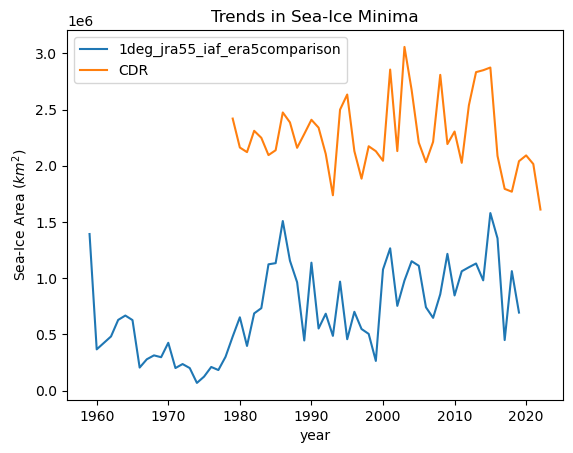

In [21]:
model_area_ds.si_area.groupby("time.year").min().plot(label=OM2_EXPT)
obs_area_ds.cdr_area.groupby("time.year").min().plot(label="CDR")

plt.title("Trends in Sea-Ice Minima")
plt.ylabel("Sea-Ice Area ($km^2$)")

_ = plt.legend()

We see that all models have sea ice area which is too low in summer. Model runs forced by JRA have more variability than those forced by ERA5 and are slightly closer to the measured sea ice area from observations.

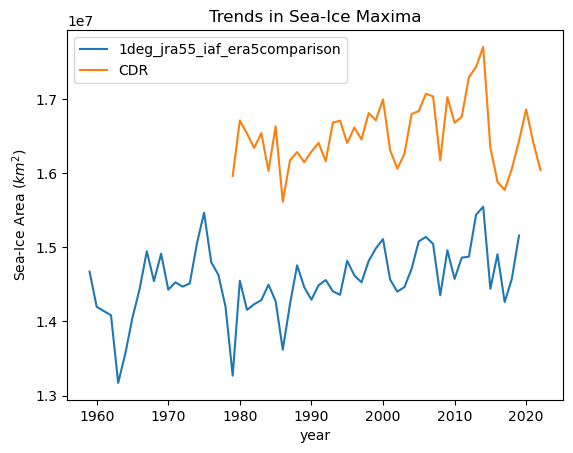

In [22]:
model_area_ds.si_area.groupby("time.year").max().plot(label=OM2_EXPT)
obs_area_ds.cdr_area.groupby("time.year").max().plot(label="CDR")

plt.title("Trends in Sea-Ice Maxima")
plt.ylabel("Sea-Ice Area ($km^2$)")

_ = plt.legend()

We see that the 1 degree resolution over-represents sea ice area in both winter and summer

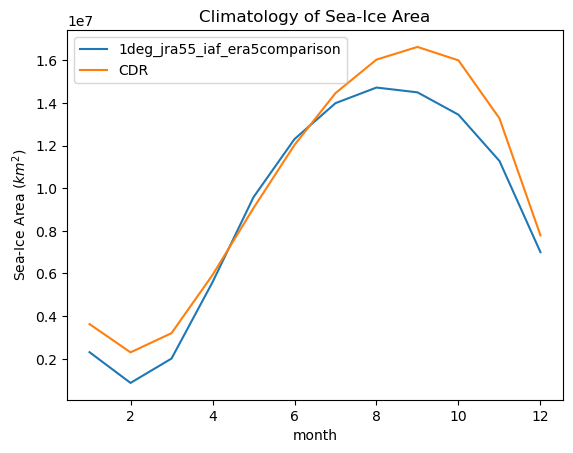

In [23]:
climatology(model_area_ds.si_area).plot(label=OM2_EXPT)
climatology(obs_area_ds.cdr_area).plot(label="CDR")

plt.title("Climatology of Sea-Ice Area")
plt.ylabel("Sea-Ice Area ($km^2$)")

_ = plt.legend()

We see all model runs have too low sea ice in summer, and grow faster than observations in autumn and earlier that the observed maximum.

# Sea Ice Concentration Anomalies

To examine the differences between the model results and observations, we calculate difference in each grid cell between observations and the experiment

As that data are on different grids, we need to regrid to compare the datasets

The lat/lon of of each cell in the observational dataset are in a different file:

In [24]:
cdr_sps_ds = xr.open_dataset(SH_OBS_LATLON_P)

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/argopy/utils/lists.py:38: UserWarning: An error occurred while loading the ERDDAP data fetcher, it will not be available !
<class 'ImportError'>
cannot import name '_quote_string_constraints' from 'erddapy.erddapy' (/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/erddapy/erddapy.py)
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/argopy/utils/lists.py:50: UserWarning: An error occurred while loading the ArgoVis data fetcher, it will not be available !
<class 'ImportError'>
cannot import name '_quote_string_constraints' from 'erddapy.erddapy' (/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/erddapy/erddapy.py)
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/argopy/utils/lists.py:66: UserWarning: An error occurred while loadi

We can now build the re-gridder. This is described in detail in [DocumentedExamples/Regridding](https://cosima-recipes.readthedocs.io/en/latest/03-Advanced-Recipes/Horizontal_Regridding.html)

In [25]:
regridder_ACCESSOM2_sh = xesmf.Regridder(
    om2_ds.isel(time=0).drop_vars(["xt_ocean", "yt_ocean"]),
    cdr_sps_ds,
    "bilinear",
    periodic=True,
    unmapped_to_nan=True,
)

In [26]:
aice_sh_3976_ds = regridder_ACCESSOM2_sh(
        om2_ds.aice_m.copy()
    )
aice_sh_anom_ds = aice_sh_3976_ds - cdr_obs_ds.cdr_conc

We can now plot the difference between modelled and observed sea ice concentration

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 207.73 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 9.91 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/distributed/cli

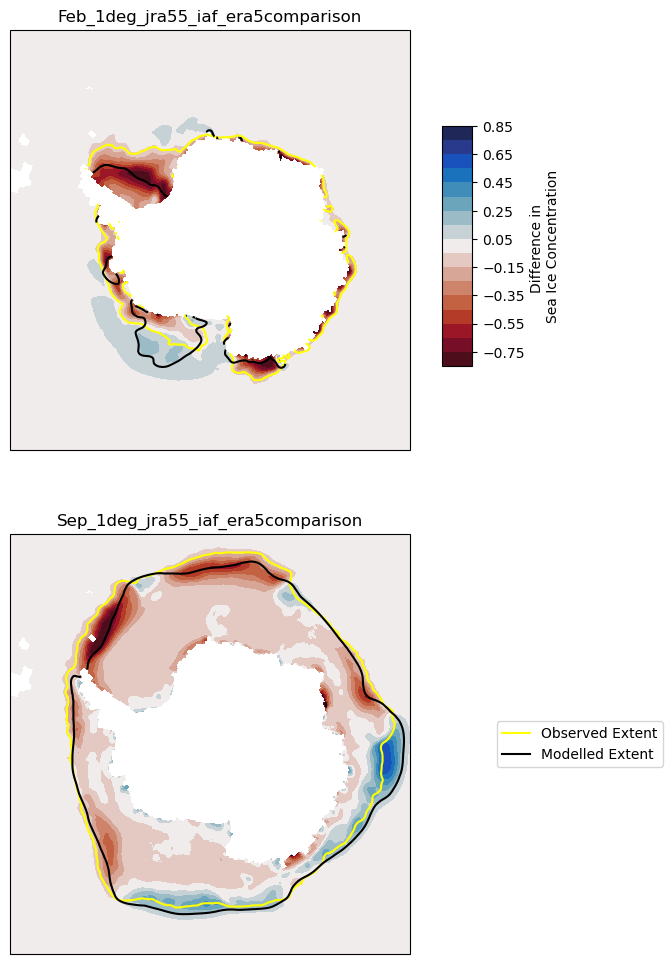

In [27]:
months = [2, 9]  # february, september
month_names = ["Feb", "Sep"]
n_months = len(months)

plt.figure(figsize=(6, n_months * 6))

cdr = climatology(cdr_obs_ds.cdr_conc)

anoms = climatology(aice_sh_anom_ds)
aice = climatology(aice_sh_3976_ds)

for i, iMonth in enumerate(months):
    plt.subplot(
        n_months,
        1,
        1 + i,
        projection=ccrs.SouthPolarStereo(true_scale_latitude=-70),
    )

    # Filled contours with concentration anomalies in this month
    ds = anoms.sel(month=iMonth).compute()
    plt.contourf(
        ds.x, ds.y, ds, levels=np.arange(-0.85, 0.86, 0.1), cmap=cmo.balance_r
    )

    # Lines at 15% concentration (approx ice edge)
    cs_cdr = cdr.sel(month=iMonth).plot.contour(levels=[0.15], colors=["yellow"])
    cs_mod = aice.sel(month=iMonth).plot.contour(levels=[0.15], colors=["black"])

    plt.title(month_names[i] + "_" + OM2_EXPT)

# Messy legend creation
line_cdr = mlines.Line2D([], [], color="yellow", label="Observed Extent")
line_mod = mlines.Line2D([], [], color="black", label="Modelled Extent")

plt.legend(handles=[line_cdr, line_mod], loc="center left", bbox_to_anchor=(1.2, 0.5))

# And colorbar
cax = plt.axes([0.9, 0.6, 0.05, 0.2])
_ = plt.colorbar(cax=cax, label="Difference in \nSea Ice Concentration")

We see that OM2 under-represents sea ice in Summer, particularly in the Weddell Sea.

# Sea Ice Volume

We can calculate volume in much the same way as sea ice area. 

In [28]:
siv = om2_ds.hi_m.cf.sel(Y=slice(-90, 0))
area_km2 = om2_ds.area_t / 1e6

model_vol_ds = sea_ice_weighted_sum(sic, area_km2, range=[0, 1]).to_dataset(name="si_vol").load()

In [29]:
model_vol_ds

<xarray.Dataset> Size: 9kB
Dimensions:  (time: 720)
Coordinates:
  * time     (time) datetime64[ns] 6kB 1959-01-01 1959-02-01 ... 2019-12-01
Data variables:
    si_vol   (time) float32 3kB 1.794e+06 1.453e+06 ... 1.13e+07 7.515e+06

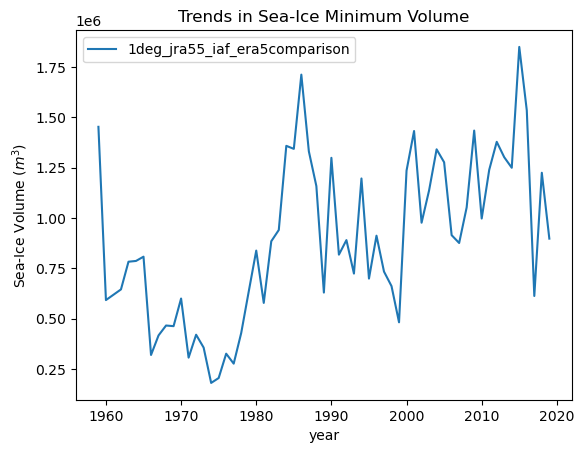

In [30]:
model_vol_ds.si_vol.groupby("time.year").min().plot(label=OM2_EXPT)

plt.title("Trends in Sea-Ice Minimum Volume")
plt.ylabel("Sea-Ice Volume ($m^3$)")

_ = plt.legend()

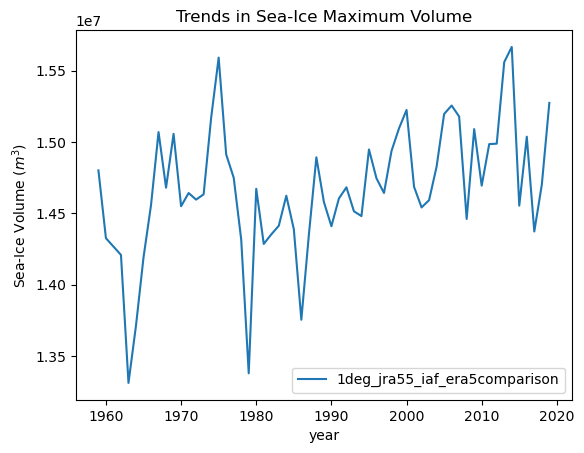

In [31]:
model_vol_ds.si_vol.groupby("time.year").max().plot(label=OM2_EXPT)


plt.title("Trends in Sea-Ice Maximum Volume")
plt.ylabel("Sea-Ice Volume ($m^3$)")

_ = plt.legend()

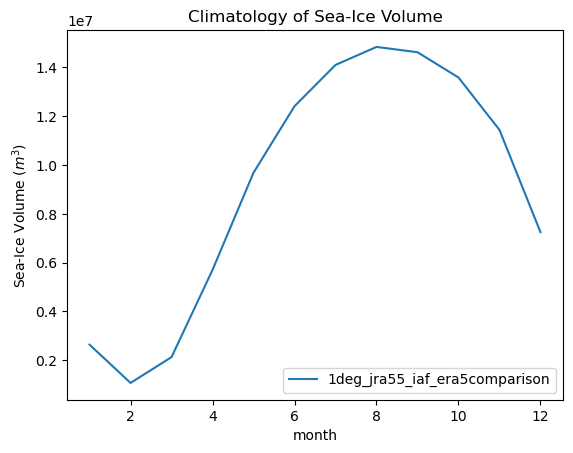

In [32]:
climatology(model_vol_ds.si_vol).plot(label=OM2_EXPT)

plt.title("Climatology of Sea-Ice Volume")
plt.ylabel("Sea-Ice Volume ($m^3$)")

_ = plt.legend()

In [33]:
client.close()